# Exploratory analysis of dataset

This notebook holds some code for an exploratory analysis of the training data from the H to Z(ll) + a (hadronic) signal process.

We first download a preprocessed file which contains information about jets and their particle flow object content.

In [ ]:
import subprocess, h5py, os

url = "https://pgadow.web.cern.ch/pgadow/share/pheno/hza_ml/train.h5" #I've not used this data type before, should I understand before getting to work?
out = "train.h5"

if not os.path.exists(out):
    subprocess.run(["wget", "-O", out, url], check=True)


In [ ]:
import numpy as np

# display the content of the file
with h5py.File(out, "r") as f:
    def print_keys(name, obj):
        print(name)
    f.visititems(print_keys) # https://docs.h5py.org/en/stable/high/group.html#h5py.Group.visititems

# explore what is in jets and tracks
with h5py.File(out, "r") as f:
    jets = f["jets"]
    tracks = f["tracks"]
    labels = f["labels"]
    print("Jets shape:", jets.shape)
    print("Tracks shape:", tracks.shape)
    print("Labels shape:", labels.shape, "| dtype:", labels.dtype)
    print("Jets variables:", jets.dtype.names)
    print("Tracks variables:", tracks.dtype.names)
    print("Jets dtype:", jets.dtype)
    print("Tracks dtype:", tracks.dtype) # What is ('valid', '?')?


jets
labels
tracks
Jets shape: (324138,)
Tracks shape: (324138, 40)
Labels shape: (324138,) | dtype: [('a_jet', '<i4')]
Jets variables: ('pt', 'eta', 'phi', 'mass', 'a_jet')
Tracks variables: ('pt', 'eta_rel', 'phi_rel', 'mass', 'charge', 'pdgId', 'dxy', 'dz', 'dxySig', 'dzSig', 'trkQuality', 'puppiWeight', 'valid')
Jets dtype: [('pt', '<f4'), ('eta', '<f4'), ('phi', '<f4'), ('mass', '<f4'), ('a_jet', '<i4')]
Tracks dtype: [('pt', '<f4'), ('eta_rel', '<f4'), ('phi_rel', '<f4'), ('mass', '<f4'), ('charge', 'i1'), ('pdgId', '<i4'), ('dxy', '<f4'), ('dz', '<f4'), ('dxySig', '<f4'), ('dzSig', '<f4'), ('trkQuality', 'i1'), ('puppiWeight', '<f4'), ('valid', '?')]


## Check jet variables

In [ ]:
!pip install mplhep
!pip install hist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.1/98.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 15.9 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.4 MB/s eta 0:00:00


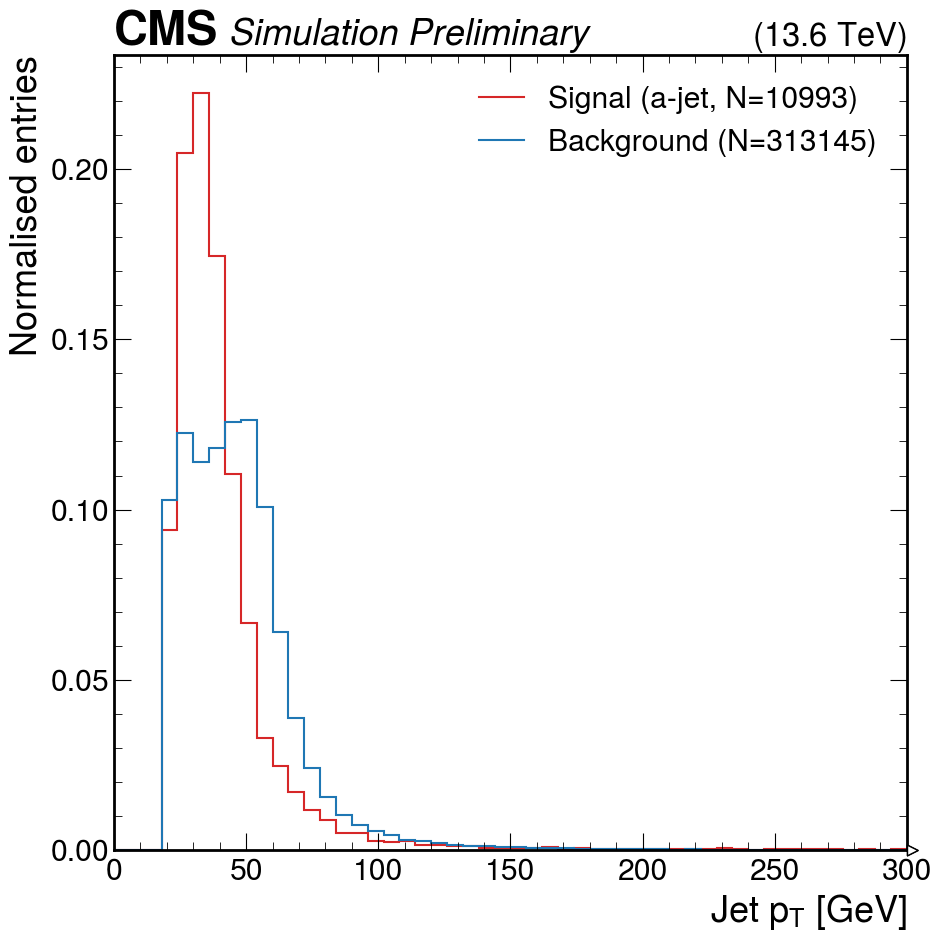

In [ ]:
import matplotlib.pyplot as plt
import mplhep as hep
import hist

hep.style.use("CMS")

with h5py.File(out, "r") as f:
    jets_pt = f["jets"]["pt"][:]
    labels  = f["labels"]["a_jet"][:]   # 1 = signal (a-jet), 0 = background

sig_pt = jets_pt[labels == 1]
bkg_pt = jets_pt[labels == 0]

h_sig = hist.Hist(hist.axis.Regular(50, 0, 300, label="Jet $p_T$ [GeV]"))
h_bkg = hist.Hist(hist.axis.Regular(50, 0, 300, label="Jet $p_T$ [GeV]"))
h_sig.fill(sig_pt)
h_bkg.fill(bkg_pt)

# normalise to unit area
h_sig_norm = h_sig / h_sig.sum()
h_bkg_norm = h_bkg / h_bkg.sum()

fig, ax = plt.subplots()
hep.histplot(h_sig_norm, ax=ax, label=f"Signal (a-jet, N={len(sig_pt)})", color="tab:red")
hep.histplot(h_bkg_norm, ax=ax, label=f"Background (N={len(bkg_pt)})", color="tab:blue")
ax.set_xlabel("Jet $p_T$ [GeV]")
ax.set_xlim(0, 300)
ax.set_ylabel("Normalised entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()


In [ ]:
# here you can make plots of other jet variables

<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3472/4010177938.py:22: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel("Jet $\phi$ [rad]")


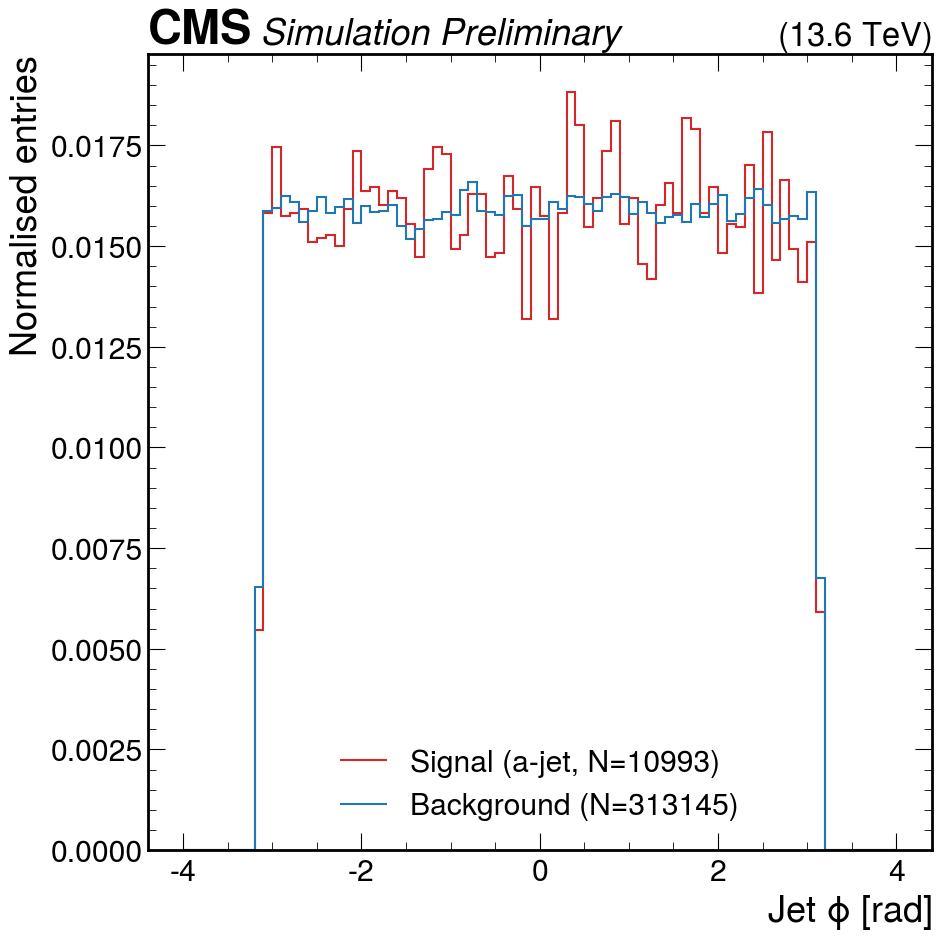

In [ ]:
hep.style.use("CMS")

with h5py.File(out, "r") as f:
    jets_phi = f["jets"]["phi"][:]
    labels  = f["labels"]["a_jet"][:]   # 1 = signal (a-jet), 0 = background

sig_phi = jets_phi[labels == 1]
bkg_phi = jets_phi[labels == 0]

h_sig = hist.Hist(hist.axis.Regular(80, -4, 4, label="Jet $phi$ [rad]"))
h_bkg = hist.Hist(hist.axis.Regular(80, -4, 4, label="Jet $phi$ [rad]"))
h_sig.fill(sig_phi)
h_bkg.fill(bkg_phi)

# normalise to unit area
h_sig_norm = h_sig / h_sig.sum()
h_bkg_norm = h_bkg / h_bkg.sum()

fig, ax = plt.subplots()
hep.histplot(h_sig_norm, ax=ax, label=f"Signal (a-jet, N={len(sig_phi)})", color="tab:red")
hep.histplot(h_bkg_norm, ax=ax, label=f"Background (N={len(bkg_phi)})", color="tab:blue")
ax.set_xlabel("Jet $\phi$ [rad]")
#ax.set_xlim(-4, 4)
ax.set_ylabel("Normalised entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\e'
<>:22: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3472/1407468864.py:22: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("Jet $\eta$")


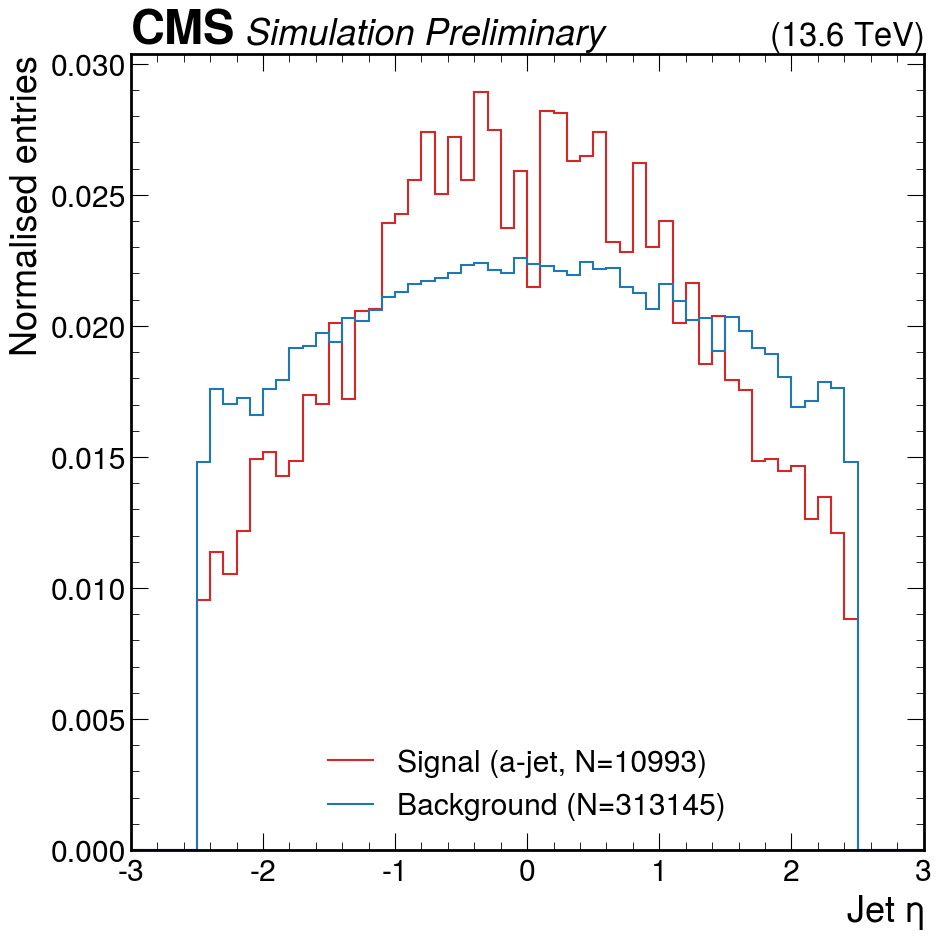

In [ ]:
hep.style.use("CMS")

with h5py.File(out, "r") as f:
    jets_mass = f["jets"]["eta"][:]
    labels  = f["labels"]["a_jet"][:]   # 1 = signal (a-jet), 0 = background

sig_eta = jets_mass[labels == 1]
bkg_eta = jets_mass[labels == 0]

h_sig = hist.Hist(hist.axis.Regular(60, -3, 3, label="Jet $eta$"))
h_bkg = hist.Hist(hist.axis.Regular(60, -3, 3, label="Jet $eta$"))
h_sig.fill(sig_eta)
h_bkg.fill(bkg_eta)

# normalise to unit area
h_sig_norm = h_sig / h_sig.sum()
h_bkg_norm = h_bkg / h_bkg.sum()

fig, ax = plt.subplots()
hep.histplot(h_sig_norm, ax=ax, label=f"Signal (a-jet, N={len(sig_eta)})", color="tab:red")
hep.histplot(h_bkg_norm, ax=ax, label=f"Background (N={len(bkg_eta)})", color="tab:blue")
ax.set_xlabel("Jet $\eta$")
ax.set_xlim(-3, 3)
ax.set_ylabel("Normalised entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

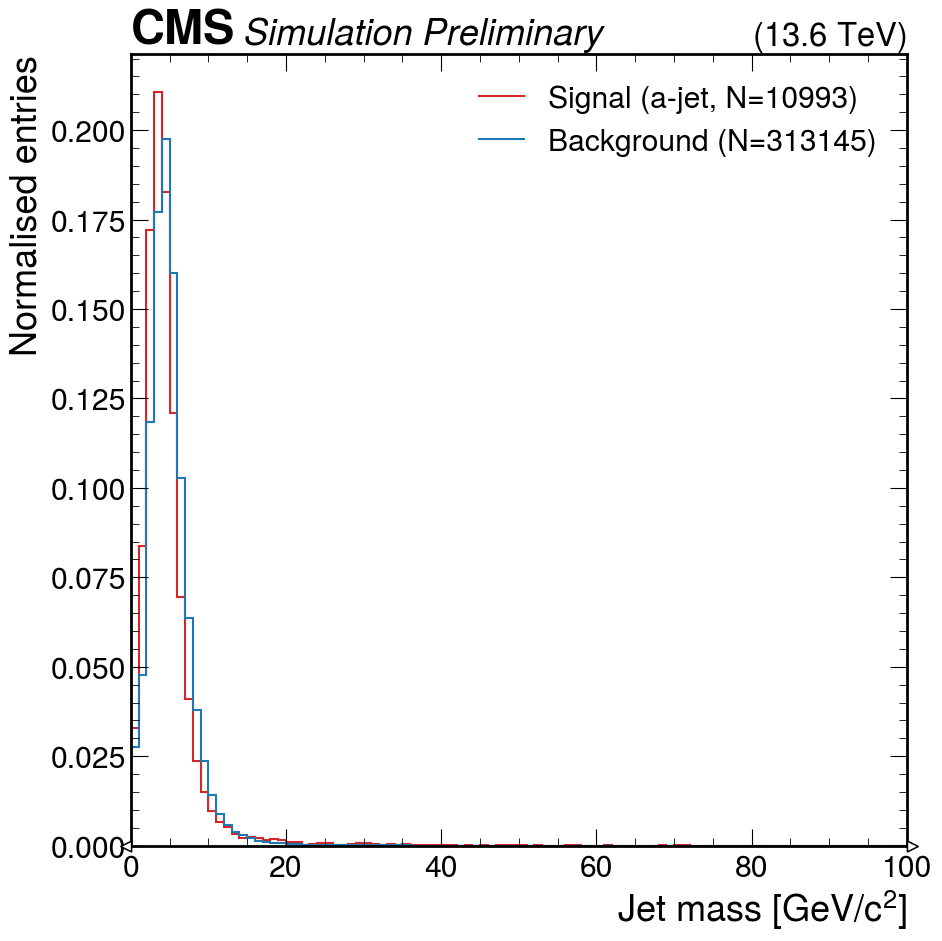

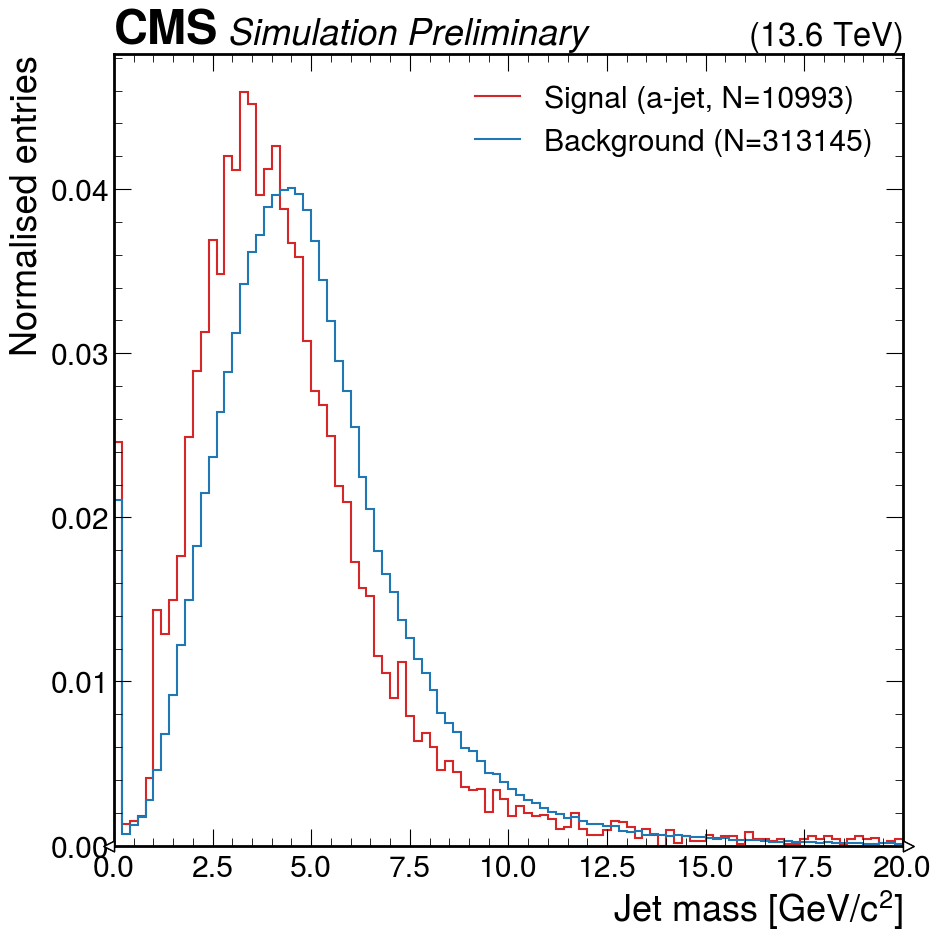

In [ ]:
hep.style.use("CMS")

with h5py.File(out, "r") as f:
    jets_mass = f["jets"]["mass"][:]
    labels  = f["labels"]["a_jet"][:]   # 1 = signal (a-jet), 0 = background

sig_mass = jets_mass[labels == 1]
bkg_mass = jets_mass[labels == 0]

h_sig = hist.Hist(hist.axis.Regular(100, 0, 100, label="Jet $phi$ [rad]"))
h_bkg = hist.Hist(hist.axis.Regular(100, 0, 100, label="Jet $phi$ [rad]"))
h_sig.fill(sig_mass)
h_bkg.fill(bkg_mass)

# normalise to unit area
h_sig_norm = h_sig / h_sig.sum()
h_bkg_norm = h_bkg / h_bkg.sum()

fig, ax = plt.subplots()
hep.histplot(h_sig_norm, ax=ax, label=f"Signal (a-jet, N={len(sig_mass)})", color="tab:red")
hep.histplot(h_bkg_norm, ax=ax, label=f"Background (N={len(bkg_mass)})", color="tab:blue")
ax.set_xlabel("Jet mass [GeV/$c^{2}$]")
ax.set_xlim(0, 100)
ax.set_ylabel("Normalised entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

# zoom
h_sig = hist.Hist(hist.axis.Regular(100, 0, 20, label="Jet $phi$ [rad]"))
h_bkg = hist.Hist(hist.axis.Regular(100, 0, 20, label="Jet $phi$ [rad]"))
h_sig.fill(sig_mass)
h_bkg.fill(bkg_mass)

# normalise to unit area
h_sig_norm = h_sig / h_sig.sum()
h_bkg_norm = h_bkg / h_bkg.sum()


fig, ax = plt.subplots()
hep.histplot(h_sig_norm, ax=ax, label=f"Signal (a-jet, N={len(sig_mass)})", color="tab:red")
hep.histplot(h_bkg_norm, ax=ax, label=f"Background (N={len(bkg_mass)})", color="tab:blue")
ax.set_xlabel("Jet mass [GeV/$c^{2}$]")
ax.set_xlim(0, 20)
ax.set_ylabel("Normalised entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

## Check track variables

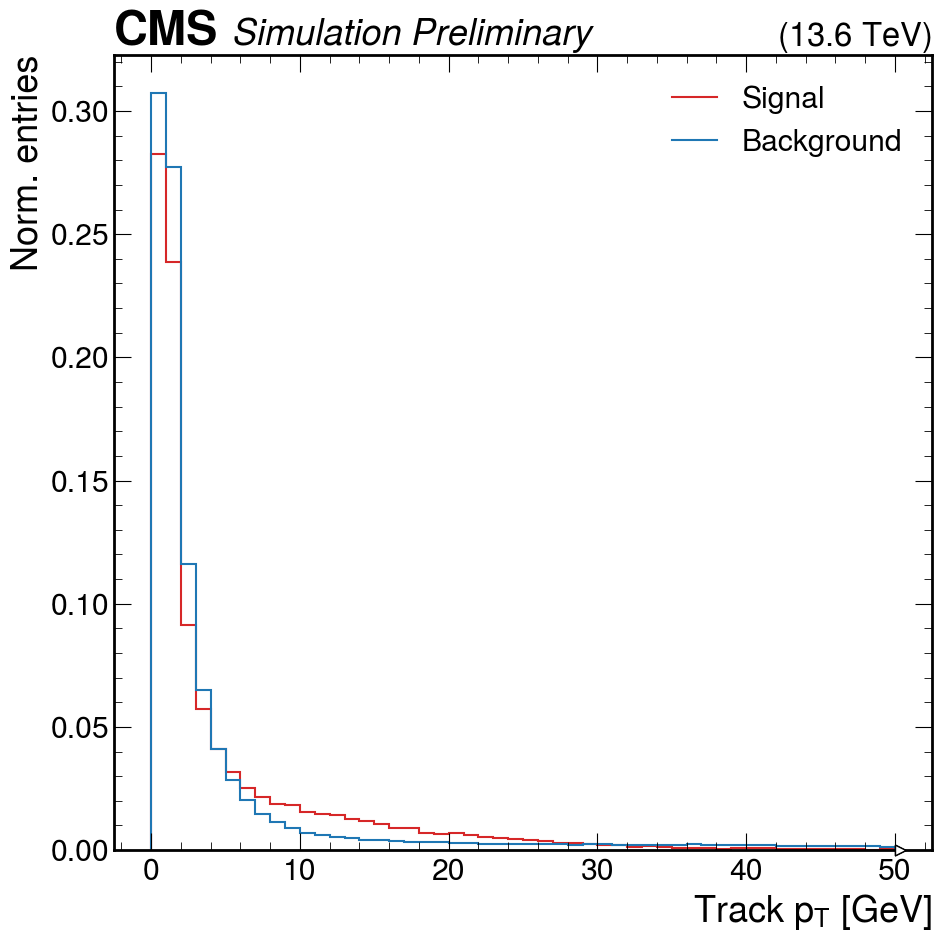

In [ ]:
N_EVENTS = 50_000  # read a subset for speed

with h5py.File(out, "r") as f:
    trk = f["tracks"][:N_EVENTS]
    lbl = f["labels"]["a_jet"][:N_EVENTS]

valid_mask = trk["valid"].ravel() # don't understand this block, need to check, what is ravel and repeat?
lbl_flat   = np.repeat(lbl, trk.shape[1])

sig_mask = valid_mask & (lbl_flat == 1)
bkg_mask = valid_mask & (lbl_flat == 0)

trk_pt = trk["pt"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(50, 0, 50, label="Track $p_T$ [GeV]"))
h_b = hist.Hist(hist.axis.Regular(50, 0, 50, label="Track $p_T$ [GeV]"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue")
ax.set_xlabel("Track $p_T$ [GeV]")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()


In [ ]:
# here you can make plots of other track variables

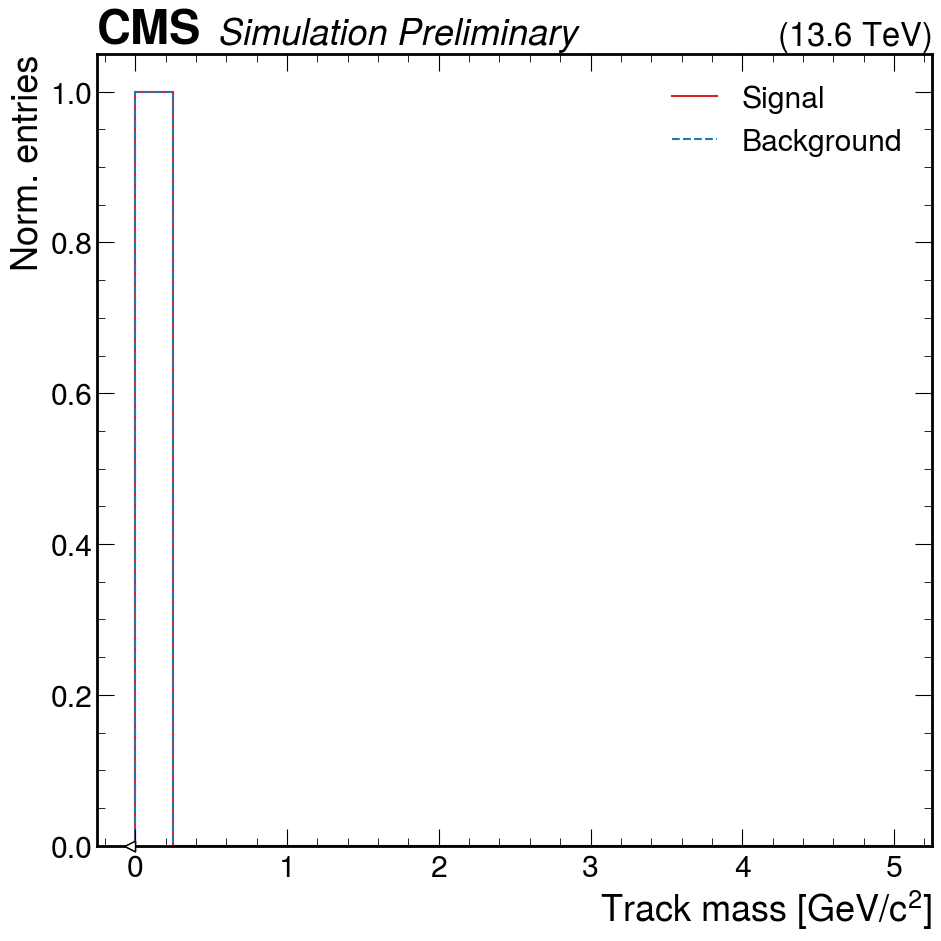

In [ ]:
trk_pt = trk["mass"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(20, 0, 5, label="Track mass [GeV/$c^2$]"))
h_b = hist.Hist(hist.axis.Regular(20, 0, 5, label="Track mass [GeV/$c^2$]"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track mass [GeV/$c^2$]")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_3472/1202897234.py:11: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel("Track $\phi_{rel}$ [rad]")


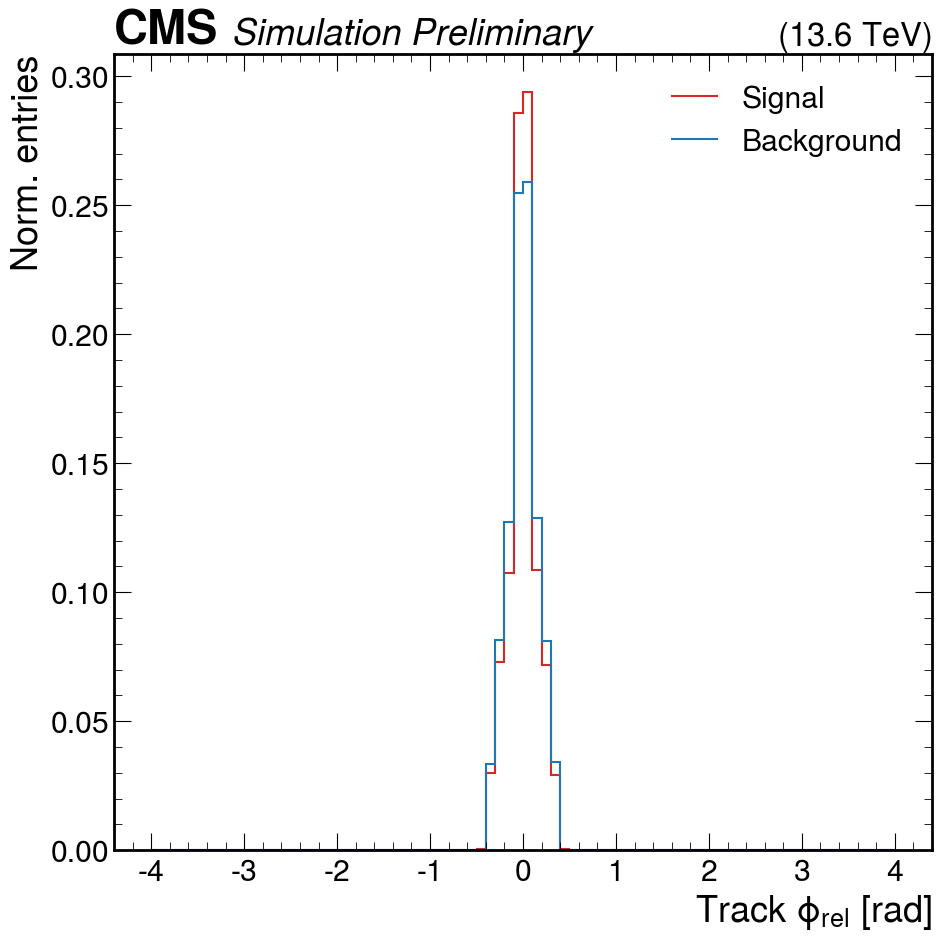

In [ ]:
trk_pt = trk["phi_rel"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(80, -4, 4, label="Track $p_T$ [GeV]"))
h_b = hist.Hist(hist.axis.Regular(80, -4, 4, label="Track $p_T$ [GeV]"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue")
ax.set_xlabel("Track $\phi_{rel}$ [rad]")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

# shows interesting peak at 0, what is phi_rel?

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3472/674419955.py:11: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel("Track $\eta_{rel}$ [rad]")


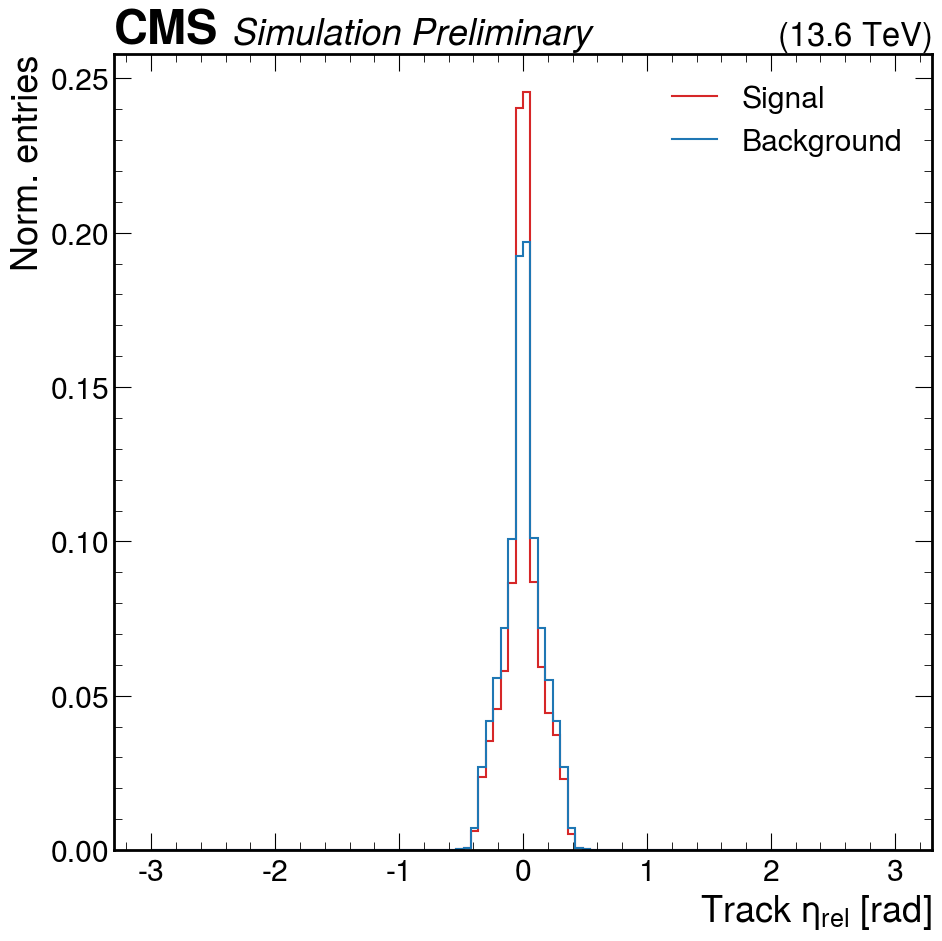

In [ ]:
trk_pt = trk["eta_rel"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(100, -3, 3, label="Track $p_T$ [GeV]"))
h_b = hist.Hist(hist.axis.Regular(100, -3, 3, label="Track $p_T$ [GeV]"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue")
ax.set_xlabel("Track $\eta_{rel}$ [rad]")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

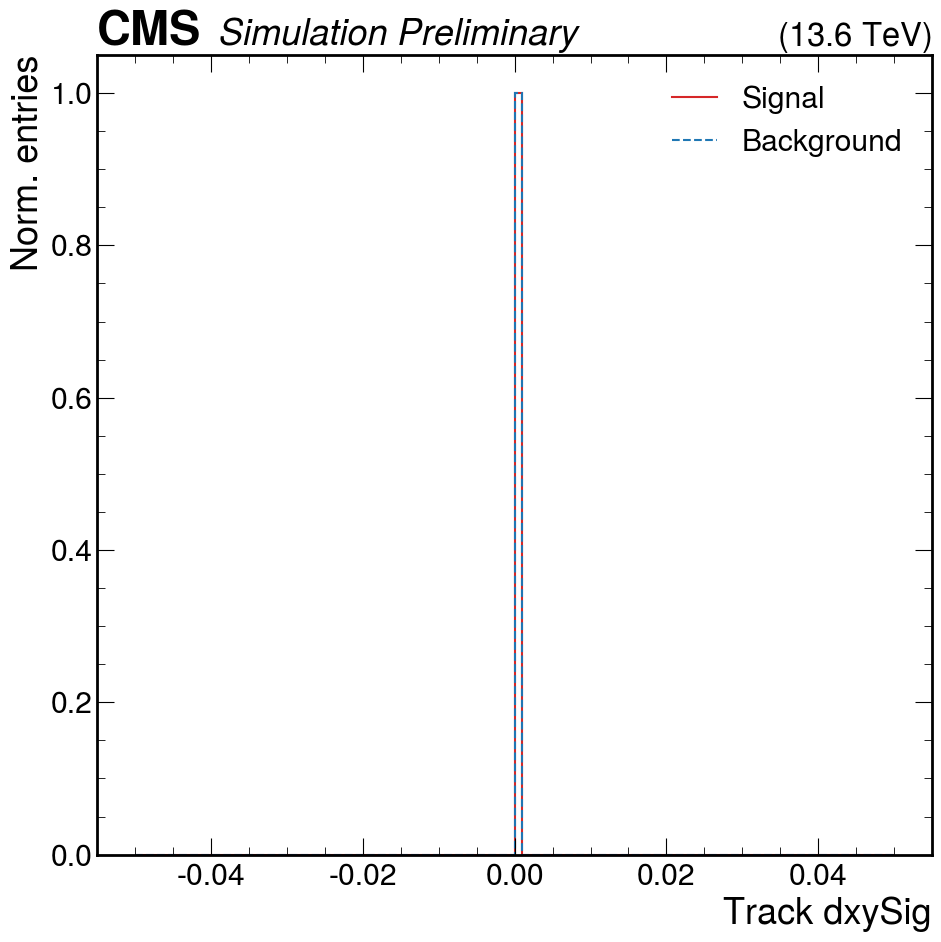

In [ ]:
trk_pt = trk["dxySig"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(100, -0.05, 0.05, label="Track dxySig"))
h_b = hist.Hist(hist.axis.Regular(100, -0.05, 0.05, label="Track dxySig"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track dxySig")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

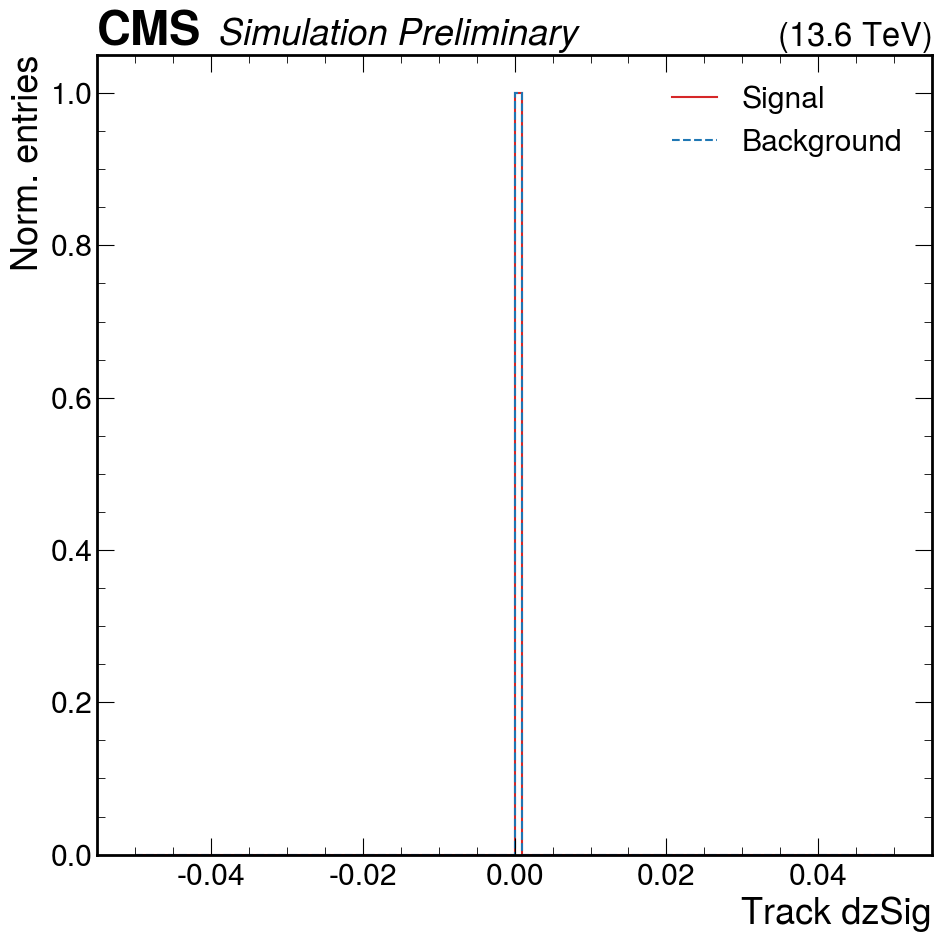

In [ ]:
trk_pt = trk["dzSig"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(100, -0.05, 0.05, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, -0.05, 0.05, label="Track dzSig"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track dzSig")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

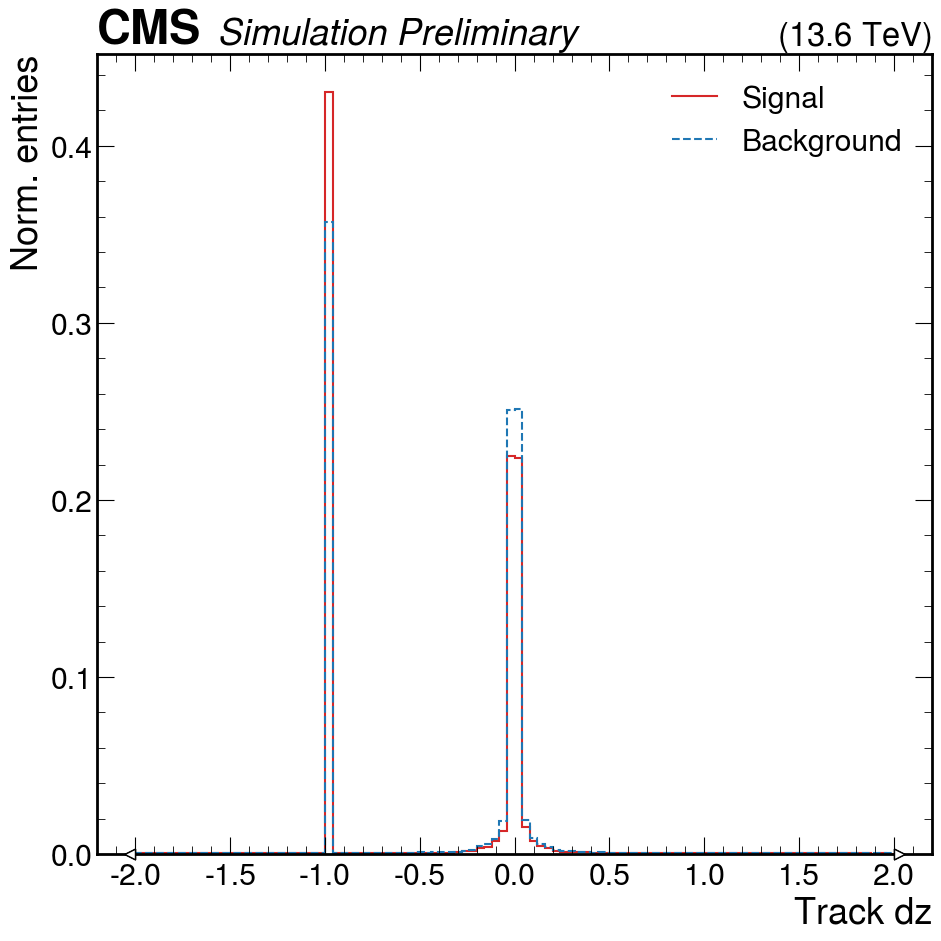

In [ ]:
trk_pt = trk["dz"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(100, -2, 2, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, -2, 2, label="Track dzSig"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track dz")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

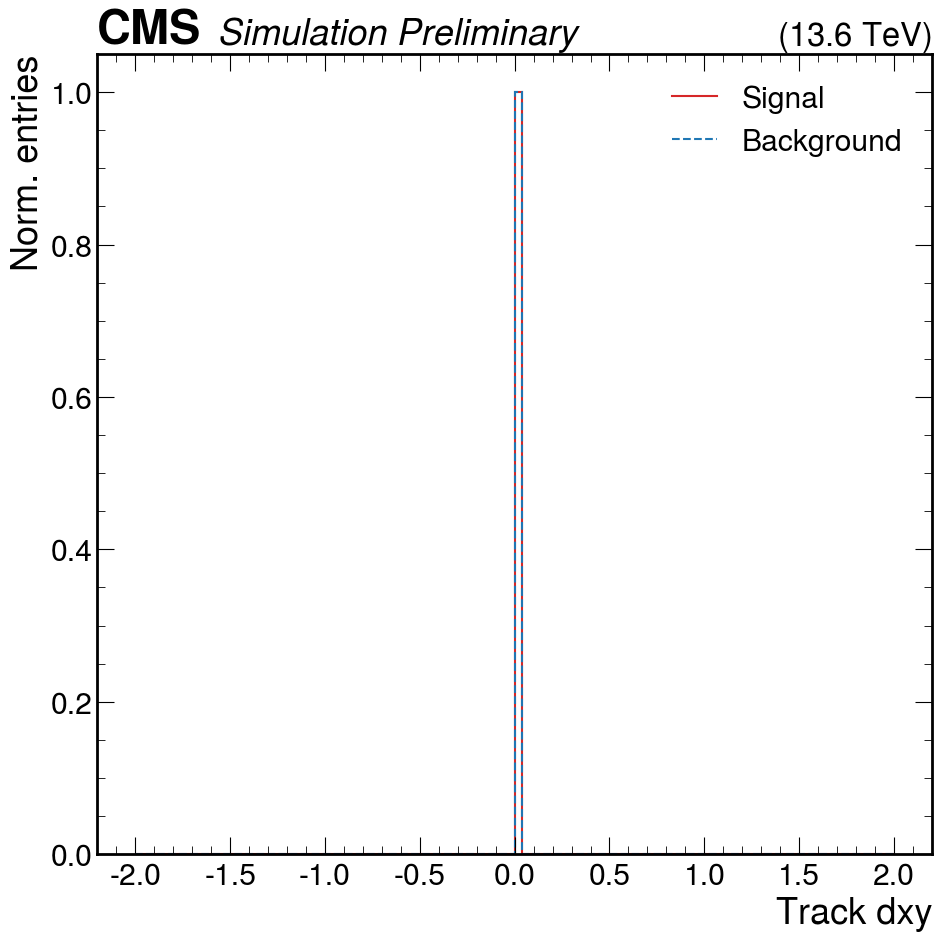

In [ ]:
trk_pt = trk["dxy"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(100, -2, 2, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, -2, 2, label="Track dzSig"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track dxy")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

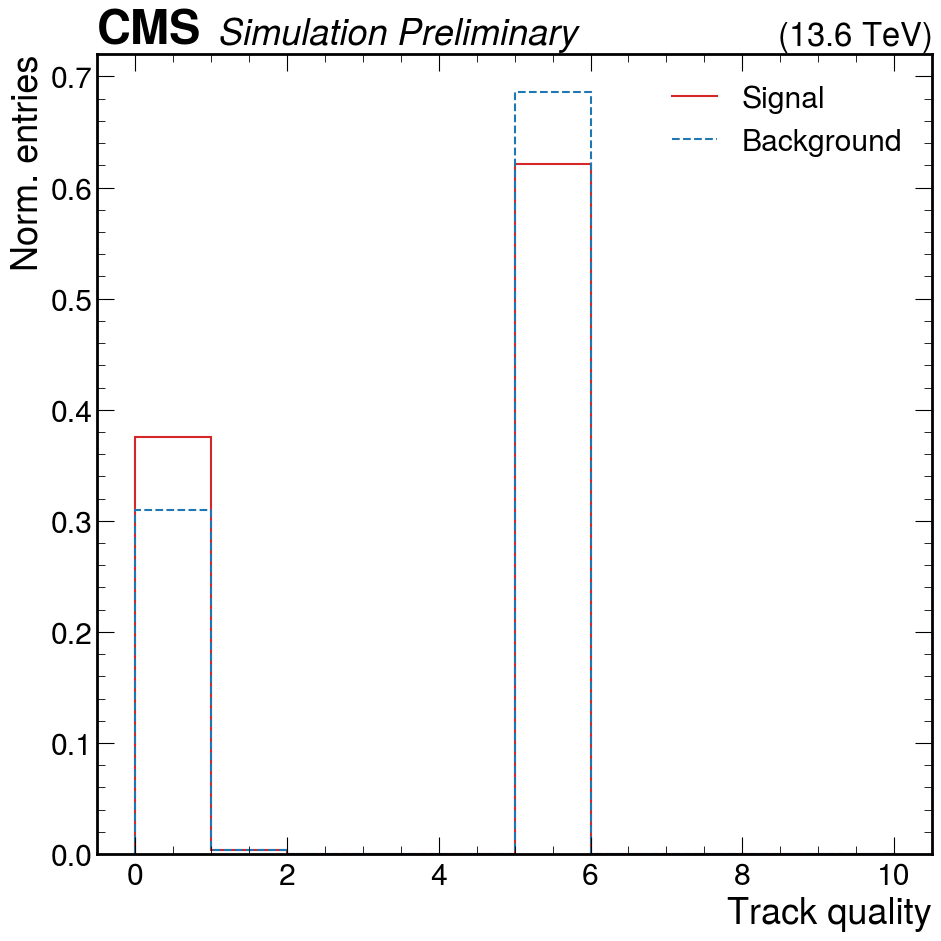

In [ ]:
trk_pt = trk["trkQuality"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(10, 0, 10, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(10, 0, 10, label="Track dzSig"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track quality")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

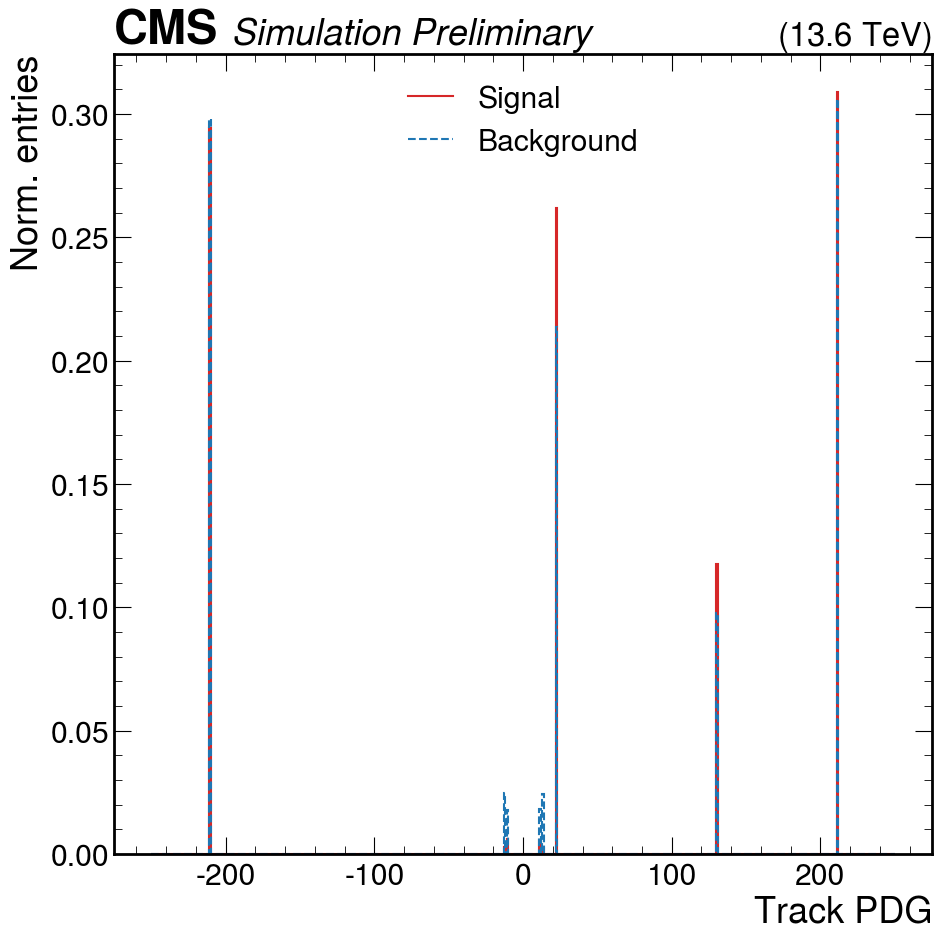

In [ ]:
trk_pt = trk["pdgId"].ravel().astype(float)

h_s = hist.Hist(hist.axis.Regular(500, -250, 250, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(500, -250, 250, label="Track dzSig"))
h_s.fill(trk_pt[sig_mask])
h_b.fill(trk_pt[bkg_mask])

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("Track PDG")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3472/381926331.py:10: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  bkg_trk_multi.append(np.sum(1 for valid in trk_valid[event] if valid != False))
/tmp/ipykernel_3472/381926331.py:8: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sig_trk_multi.append(np.sum(1 for valid in trk_valid[event] if valid != False))


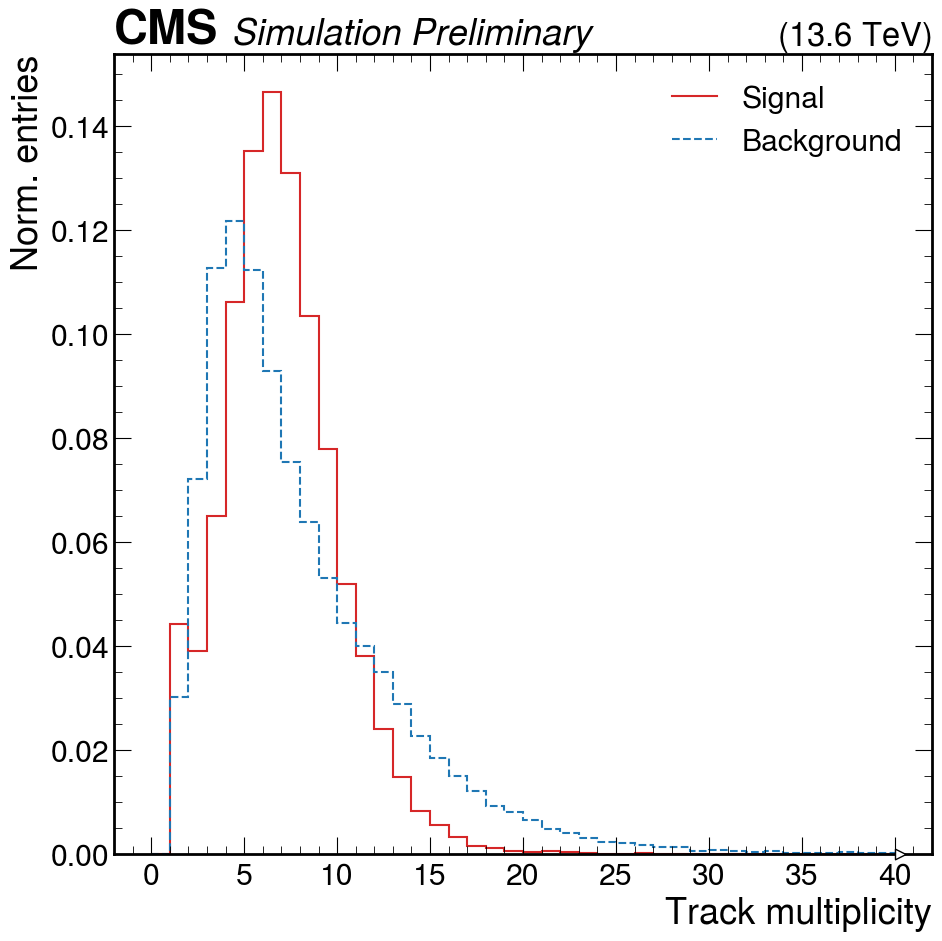

In [ ]:
sig_trk_multi = []
bkg_trk_multi = []

trk_valid = trk['valid']

for event in range(trk.shape[0]):
  if isSig(event):
    sig_trk_multi.append(np.sum(1 for valid in trk_valid[event] if valid != False))
  else:
    bkg_trk_multi.append(np.sum(1 for valid in trk_valid[event] if valid != False))

# trk multi
h_s = hist.Hist(hist.axis.Regular(40, 0, 40, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(40, 0, 40, label="Track dzSig"))
h_s.fill(sig_trk_multi)
h_b.fill(bkg_trk_multi)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"Track multiplicity")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:117: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_3472/2774796977.py:84: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$p_T^{\mathrm{leading\ track}}$")
/tmp/ipykernel_3472/2774796977.py:117: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$p_T^{\mathrm{sub-leading\ track}}$")
/tmp/ipykernel_3472/2774796977.py:36: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  sig_trk_multi.append(np.sum(1 for valid in trk_valid[event] if valid != False))


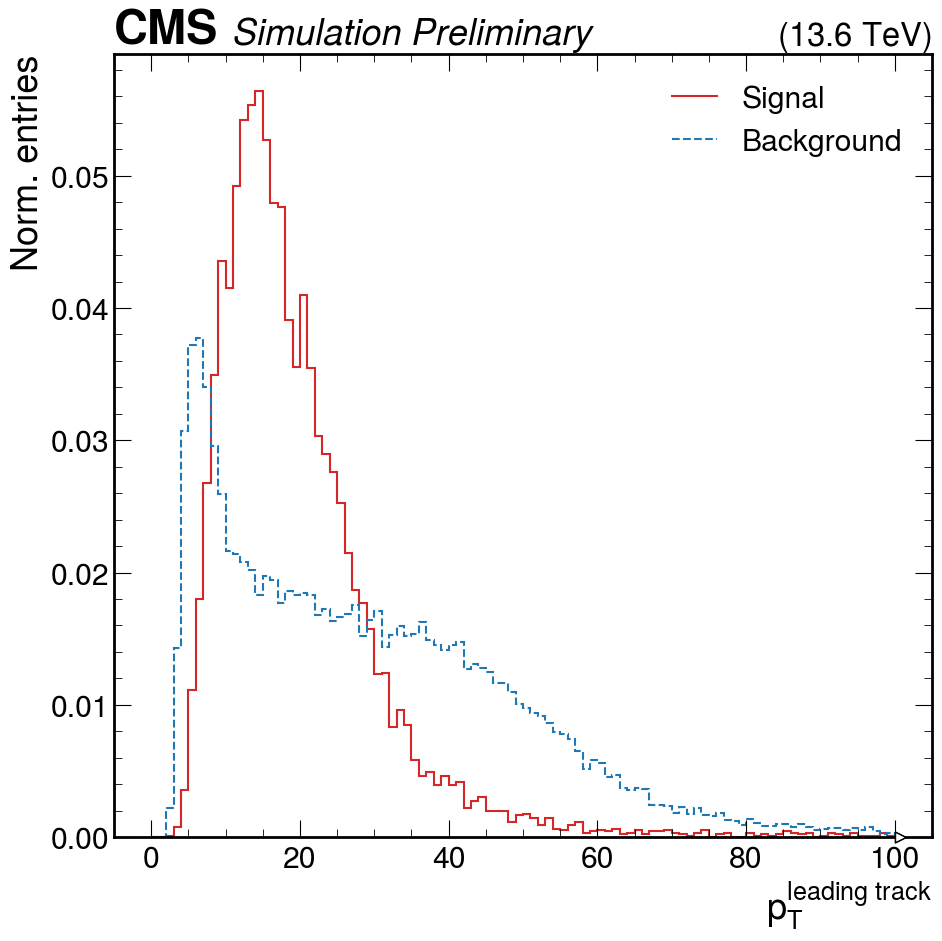

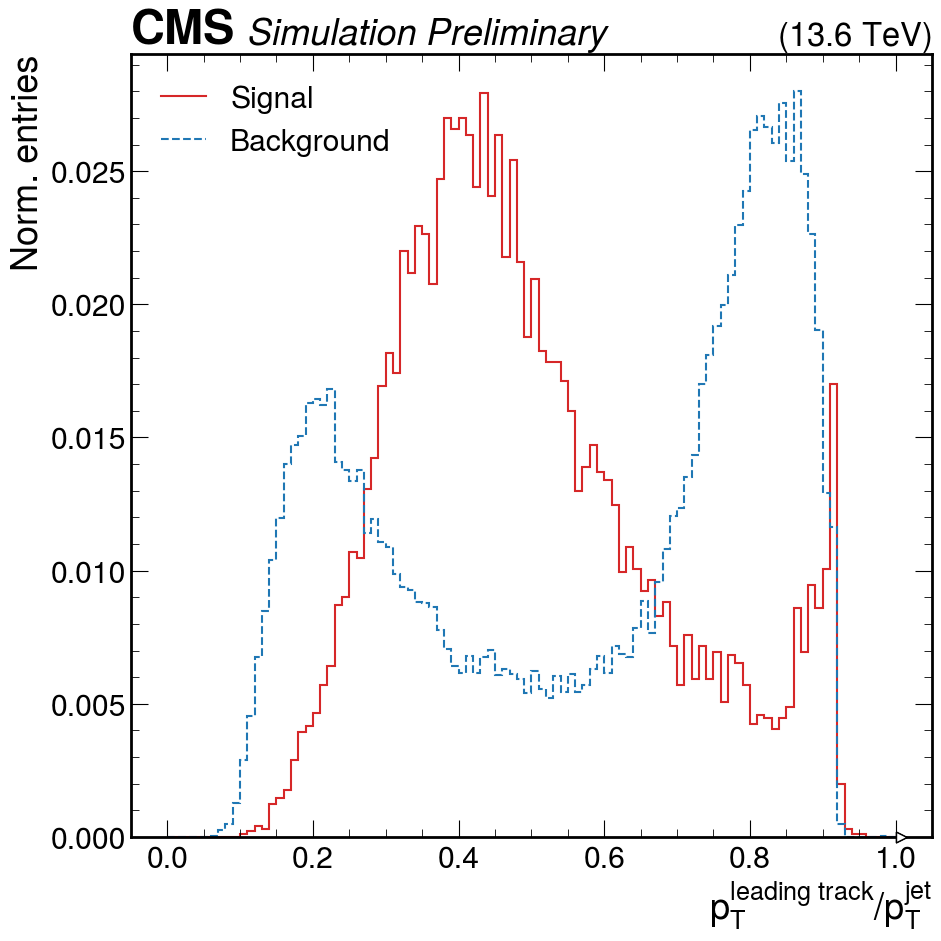

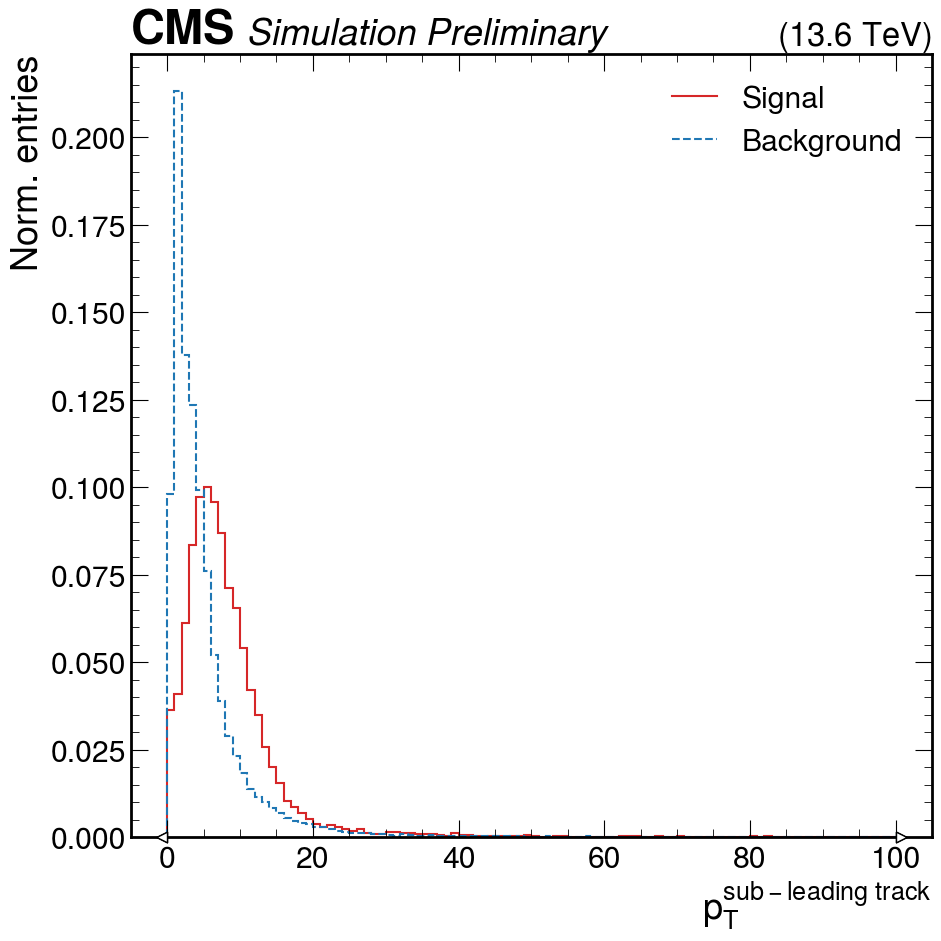

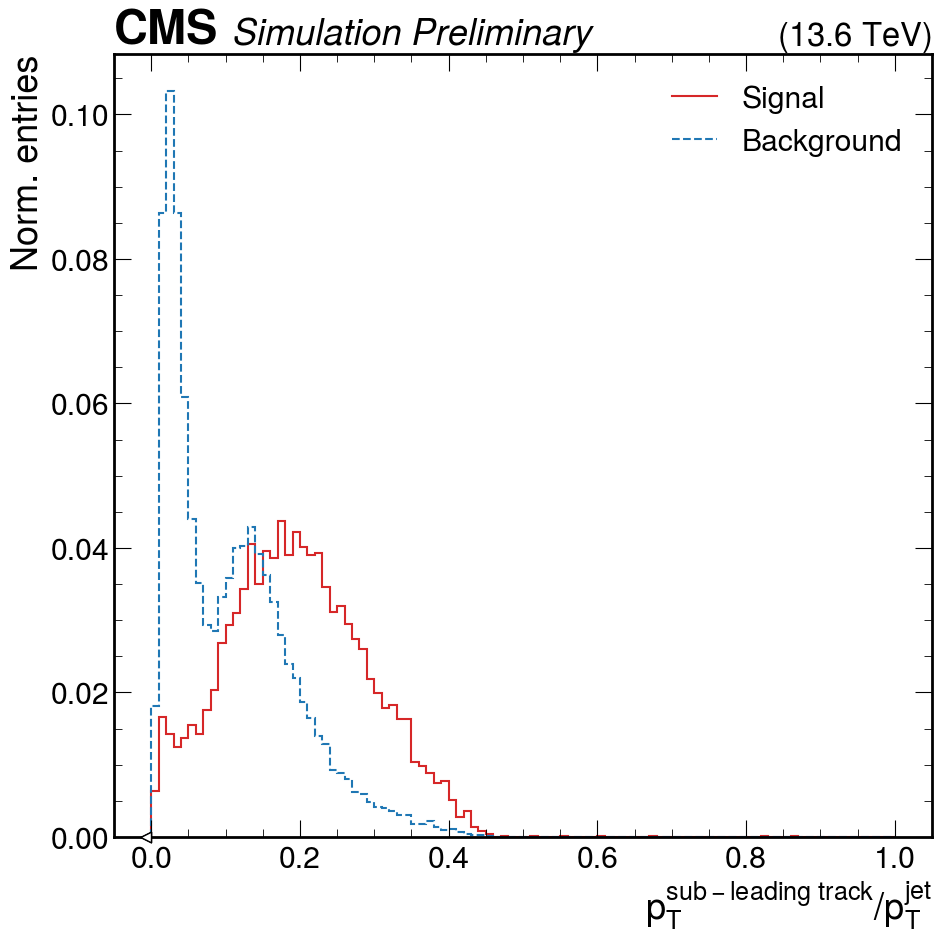

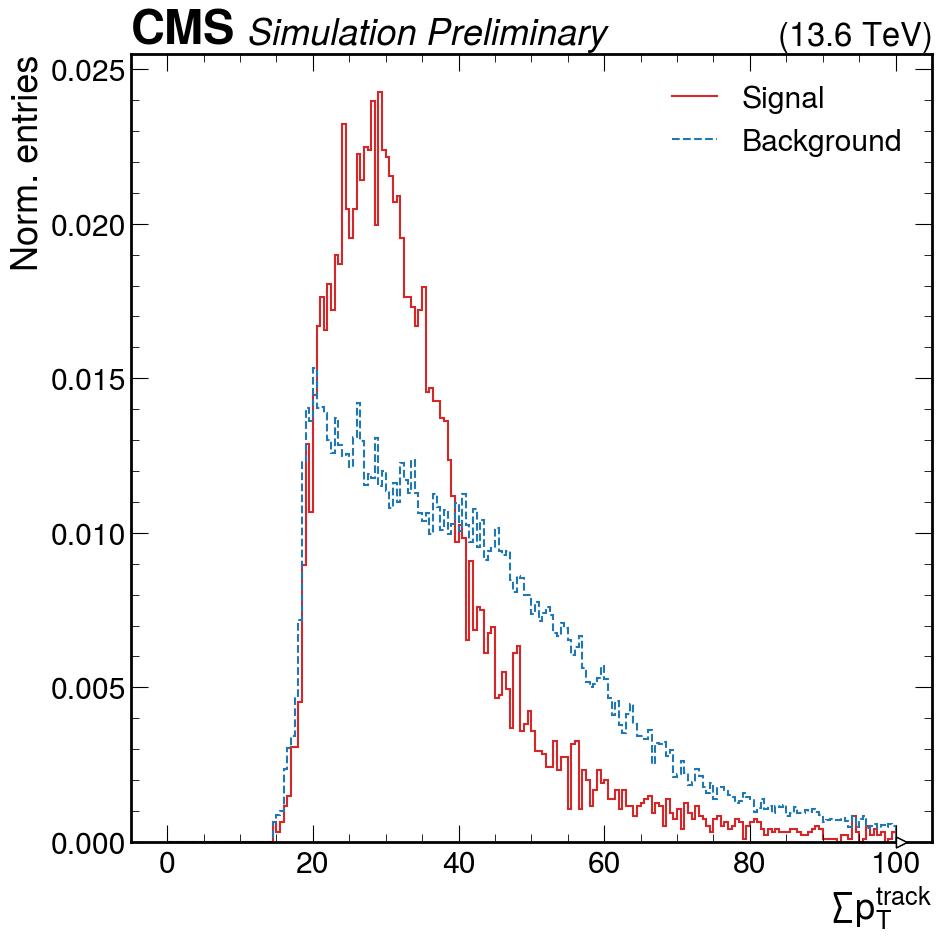

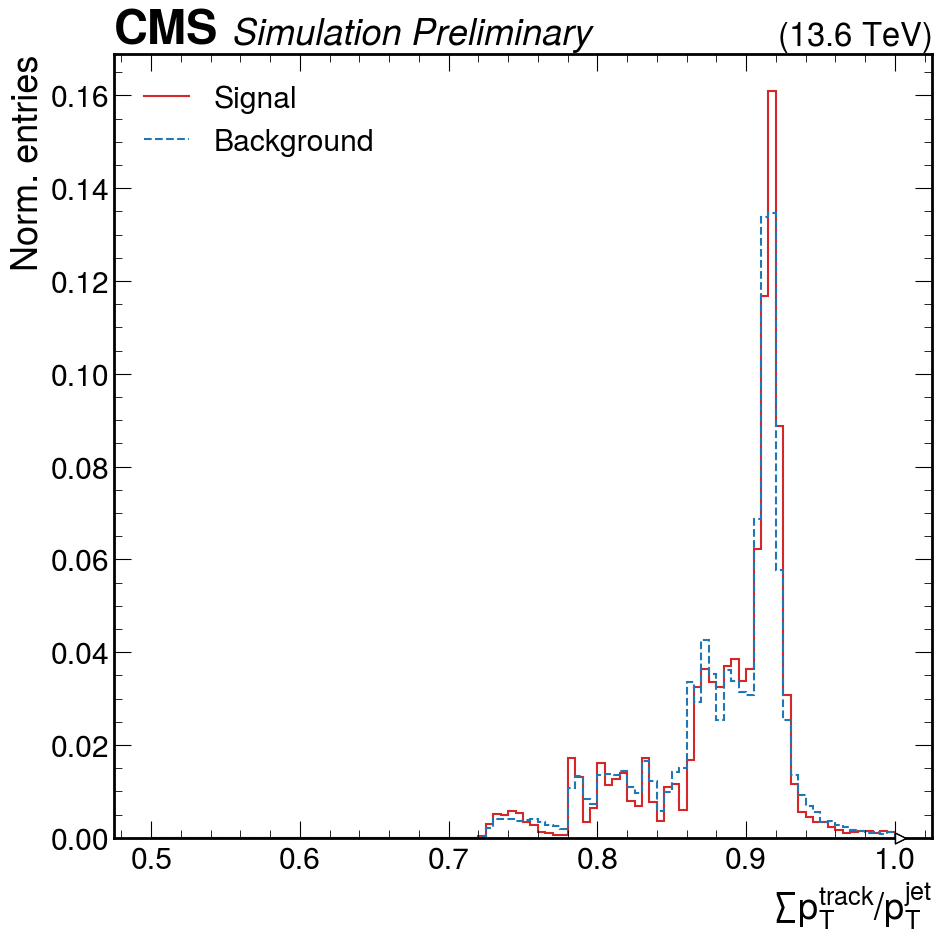

In [ ]:
N_EVENTS = 50_000  # read a subset for speed
with h5py.File(out, "r") as f:
    jets = f["jets"][:N_EVENTS]
    trk = f["tracks"][:N_EVENTS]
    lbl = f["labels"]["a_jet"][:N_EVENTS]   # 1 = signal (a-jet), 0 = background

def isSig(event):
  if lbl[event] == 1: return True
  else: return False


# get leading track pT and sums for each event
sig_lead_pT = []
sig_rel_lead_pT = []
sig_sum_trk_pT = []
sig_rel_sum_trk_pT = []

bkg_lead_pT = []
bkg_rel_lead_pT = []
bkg_sum_trk_pT = []
bkg_rel_sum_trk_pT = []

# get sub-leading track pT for each event
sig_sub_lead_pT = []
sig_rel_sub_lead_pT = []

bkg_sub_lead_pT = []
bkg_rel_sub_lead_pT = []

for event in range(trk.shape[0]):
  if isSig(event):
    pts = np.array([pt for pt, val in zip(trk["pt"][event], trk_valid[event]) if val])
    pts = np.sort(pts,)[::-1]

    # get sum and leading pTs for the trks
    sig_trk_multi.append(np.sum(1 for valid in trk_valid[event] if valid != False))
    sum = pts.sum()
    lead_pT = pts[0]
    sub_lead_pT = pts[1] if len(pts) > 1 else -1

    if lead_pT == 0.0 or lead_pT is None or sum == 0: continue # ensure nonzero

    # add to arrs
    sig_lead_pT.append(lead_pT)
    sig_sum_trk_pT.append(sum)
    sig_sub_lead_pT.append(sub_lead_pT)

    # relative arrs
    sig_rel_lead_pT.append(lead_pT / jets["pt"][event])
    sig_rel_sum_trk_pT.append(sum / jets["pt"][event])
    sig_rel_sub_lead_pT.append(sub_lead_pT / jets["pt"][event])
  else:
    pts = np.array([pt for pt, val in zip(trk["pt"][event], trk_valid[event]) if val]) # get trk pTs for this event
    pts = np.sort(pts)[::-1]

    # get sum and leading pTs for the trks
    sum = pts.sum()
    lead_pT = pts[0]
    sub_lead_pT = pts[1] if len(pts) > 1 else -1

    if lead_pT == 0.0 or lead_pT is None or sum == 0: continue # ensure nonzero

    # add to arrs
    bkg_lead_pT.append(lead_pT)
    bkg_sum_trk_pT.append(sum)
    bkg_sub_lead_pT.append(sub_lead_pT)

    # relative arrs
    bkg_rel_lead_pT.append(lead_pT / jets["pt"][event])
    bkg_rel_sum_trk_pT.append(sum / jets["pt"][event])
    bkg_rel_sub_lead_pT.append(sub_lead_pT / jets["pt"][event])



# leading track pT only
h_s = hist.Hist(hist.axis.Regular(100, 0, 100, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, 0, 100, label="Track dzSig"))
h_s.fill(sig_lead_pT)
h_b.fill(bkg_lead_pT)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("$p_T^{\mathrm{leading\ track}}$")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()


# relative leading track pT
h_s = hist.Hist(hist.axis.Regular(100, 0, 1, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, 0, 1, label="Track dzSig"))
h_s.fill(sig_rel_lead_pT)
h_b.fill(bkg_rel_lead_pT)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"$p_T^{\mathrm{leading\ track}} / p_T^{\mathrm{jet}}$")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

# sib leading track pT only
h_s = hist.Hist(hist.axis.Regular(100, 0, 100, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, 0, 100, label="Track dzSig"))
h_s.fill(sig_sub_lead_pT)
h_b.fill(bkg_sub_lead_pT)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel("$p_T^{\mathrm{sub-leading\ track}}$")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()


# relative sub leading track pT
h_s = hist.Hist(hist.axis.Regular(100, 0, 1, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, 0, 1, label="Track dzSig"))
h_s.fill(sig_rel_sub_lead_pT)
h_b.fill(bkg_rel_sub_lead_pT)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"$p_T^{\mathrm{sub-leading\ track}} / p_T^{\mathrm{jet}}$")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

# sum track pT
h_s = hist.Hist(hist.axis.Regular(200, 0, 100, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(200, 0, 100, label="Track dzSig"))
h_s.fill(sig_sum_trk_pT)
h_b.fill(bkg_sum_trk_pT)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"$\sum p_T^{\mathrm{track}}$")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

# rel sum track pT
h_s = hist.Hist(hist.axis.Regular(100, 0.5, 1.0, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, 0.5, 1.0, label="Track dzSig"))
h_s.fill(sig_rel_sum_trk_pT)
h_b.fill(bkg_rel_sum_trk_pT)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"$\sum p_T^{\mathrm{track}} / p_T^{\mathrm{jet}}$")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

In [ ]:
import math

sig_dR = []
bkg_dR = []

trk_valid = trk['valid']
trk_eta_rel = trk['eta_rel']
trk_phi_rel = trk['phi_rel']

for event in range(trk.shape[0]):
  dRs = [math.sqrt(deta**2 + dphi**2) for deta, dphi, valid in zip(trk_eta_rel[event], trk_phi_rel[event], trk_valid[event]) if valid]
  if isSig(event):
    sig_dR.append(dRs)
  else:
    bkg_dR.append(dRs)

mean_sig_dR = [np.mean(dR) for dR in sig_dR]
mean_bkg_dR = [np.mean(dR) for dR in bkg_dR]

max_sig_dR = [np.max(dR) for dR in sig_dR]
max_bkg_dR = [np.max(dR) for dR in bkg_dR]

# mean dR
h_s = hist.Hist(hist.axis.Regular(50, 0, 0.5, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(50, 0, 0.5, label="Track dzSig"))
h_s.fill(mean_sig_dR)
h_b.fill(mean_bkg_dR)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"Mean Track dR")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()

# max dR
h_s = hist.Hist(hist.axis.Regular(100, 0, 1, label="Track dzSig"))
h_b = hist.Hist(hist.axis.Regular(100, 0, 1, label="Track dzSig"))
h_s.fill(max_sig_dR)
h_b.fill(max_bkg_dR)

fig, ax = plt.subplots()
hep.histplot(h_s / h_s.sum(), ax=ax, label="Signal",     color="tab:red")
hep.histplot(h_b / h_b.sum(), ax=ax, label="Background", color="tab:blue", linestyle="--")
ax.set_xlabel(r"Max Track dR")
ax.set_ylabel("Norm. entries")
ax.legend()
hep.cms.label("Preliminary", data=False, ax=ax, com=13.6)
plt.tight_layout()
plt.show()
